# Evaluation of Trading Strategy Performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- Load equity curves ---
df = pd.read_csv("equity_curves.csv", index_col='Date', parse_dates=True)

# Ensure columns are float
df = df.astype(float)

### Equity Curve vs BUY & HOLD 

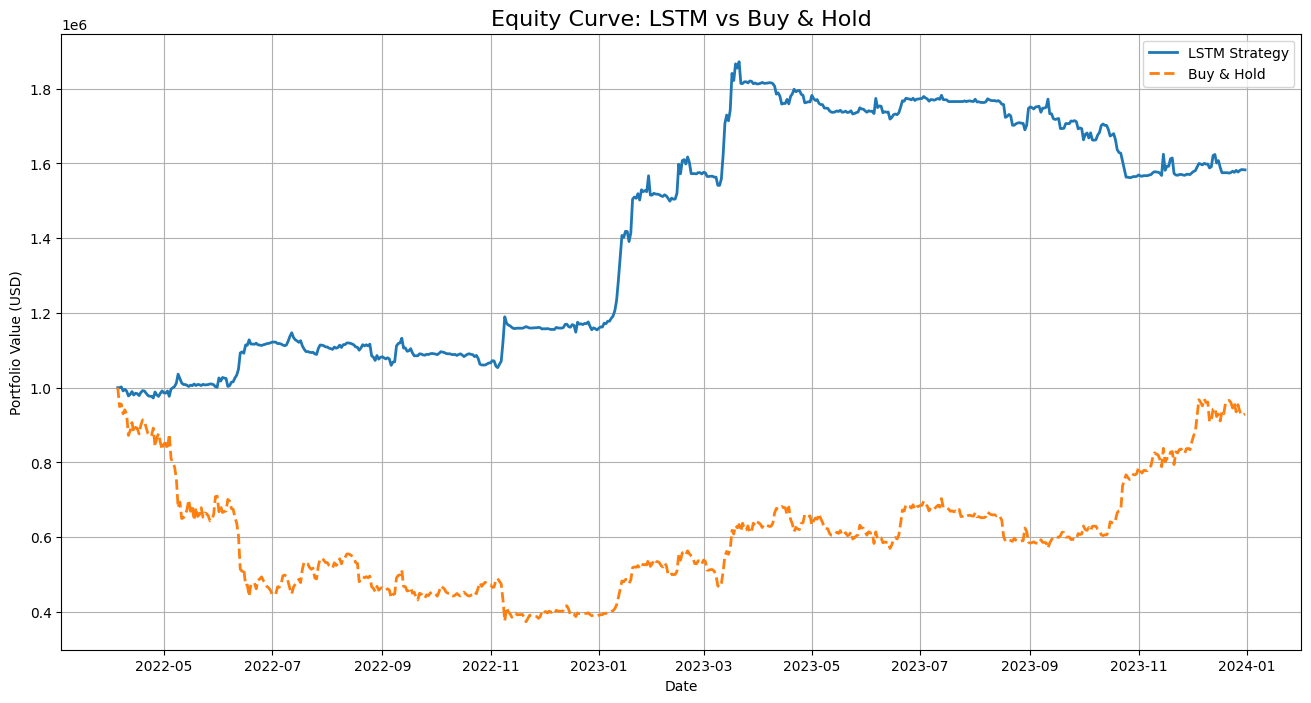

In [3]:
# --- Plot equity curves ---
plt.figure(figsize=(16, 8))
plt.plot(df.index, df['LSTM'], label="LSTM Strategy", linewidth=2)
plt.plot(df.index, df['BuyHold'], label="Buy & Hold", linewidth=2, linestyle='--')
plt.title("Equity Curve: LSTM vs Buy & Hold", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Portfolio Value (USD)")
plt.legend()
plt.grid(True)
plt.show()

### Rolling Sharpe Ratio

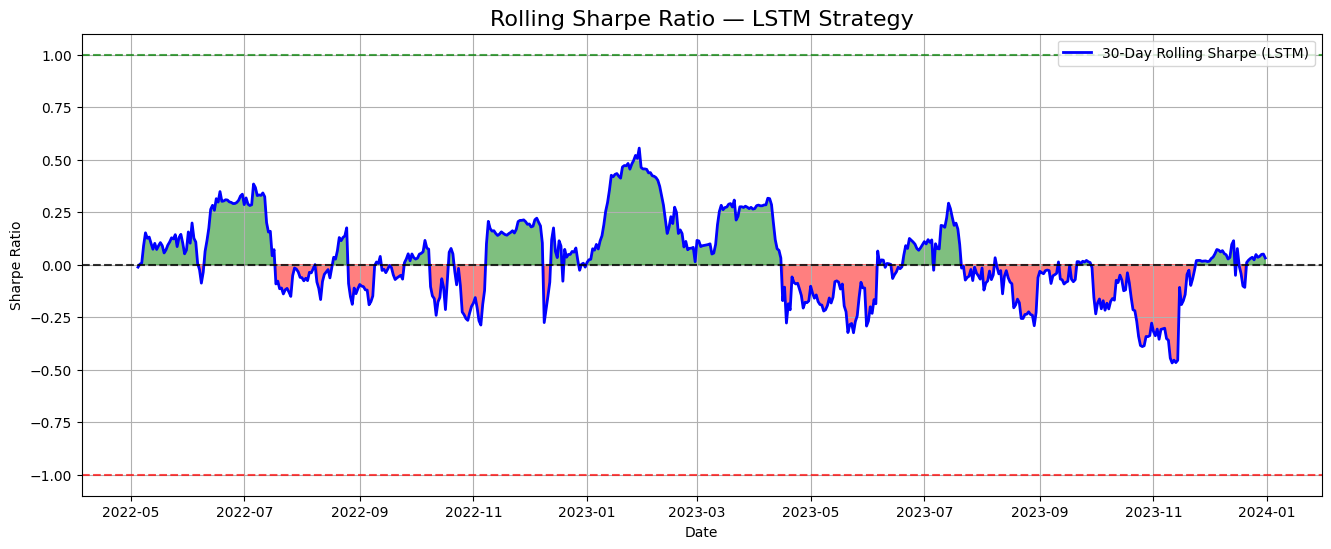

In [4]:
# --- Rolling Sharpe Ratio ---
window = 30  # trading days

# Compute daily returns for LSTM strategy
returns = df['LSTM'].pct_change()

rolling_mean = returns.rolling(window).mean()
rolling_std = returns.rolling(window).std()
rolling_sharpe = rolling_mean / (rolling_std + 1e-9)  # avoid div by zero

plt.figure(figsize=(16, 6))

# Plot the rolling Sharpe
plt.plot(df.index, rolling_sharpe, label=f"{window}-Day Rolling Sharpe (LSTM)", color='blue', linewidth=2)

# Shade regions above/below zero
plt.fill_between(df.index, rolling_sharpe, 0, 
                 where=rolling_sharpe >= 0, color='green', alpha=0.5)
plt.fill_between(df.index, rolling_sharpe, 0, 
                 where=rolling_sharpe < 0, color='red', alpha=0.5)

# Reference lines
plt.axhline(1, linestyle='--', color='green', alpha=0.7)
plt.axhline(0, linestyle='--', color='black', alpha=0.8)
plt.axhline(-1, linestyle='--', color='red', alpha=0.7)

# Labels & styling
plt.title("Rolling Sharpe Ratio — LSTM Strategy", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.show()


### Trade Analysis

=== High-level ===
              rows: 88
     opp_long_bars: 28
    opp_short_bars: 29
      entries_long: 28
     entries_short: 29
     hit_rate_long: 1.0
    hit_rate_short: 1.0

=== When LONG opportunity existed, fraction of bars blocked by reason ===
blocked_cooldown           0.0
blocked_below_thr_long     0.0
blocked_below_thr_short    0.0
blocked_size_zero          0.0
blocked_edge_near_zero     0.0
edge_exit_bar              0.0
max_hold_bar               0.0
already_in_pos             0.0

=== When SHORT opportunity existed, fraction of bars blocked by reason ===
blocked_cooldown           0.0
blocked_below_thr_long     0.0
blocked_below_thr_short    0.0
blocked_size_zero          0.0
blocked_edge_near_zero     0.0
edge_exit_bar              0.0
max_hold_bar               0.0
already_in_pos             0.0


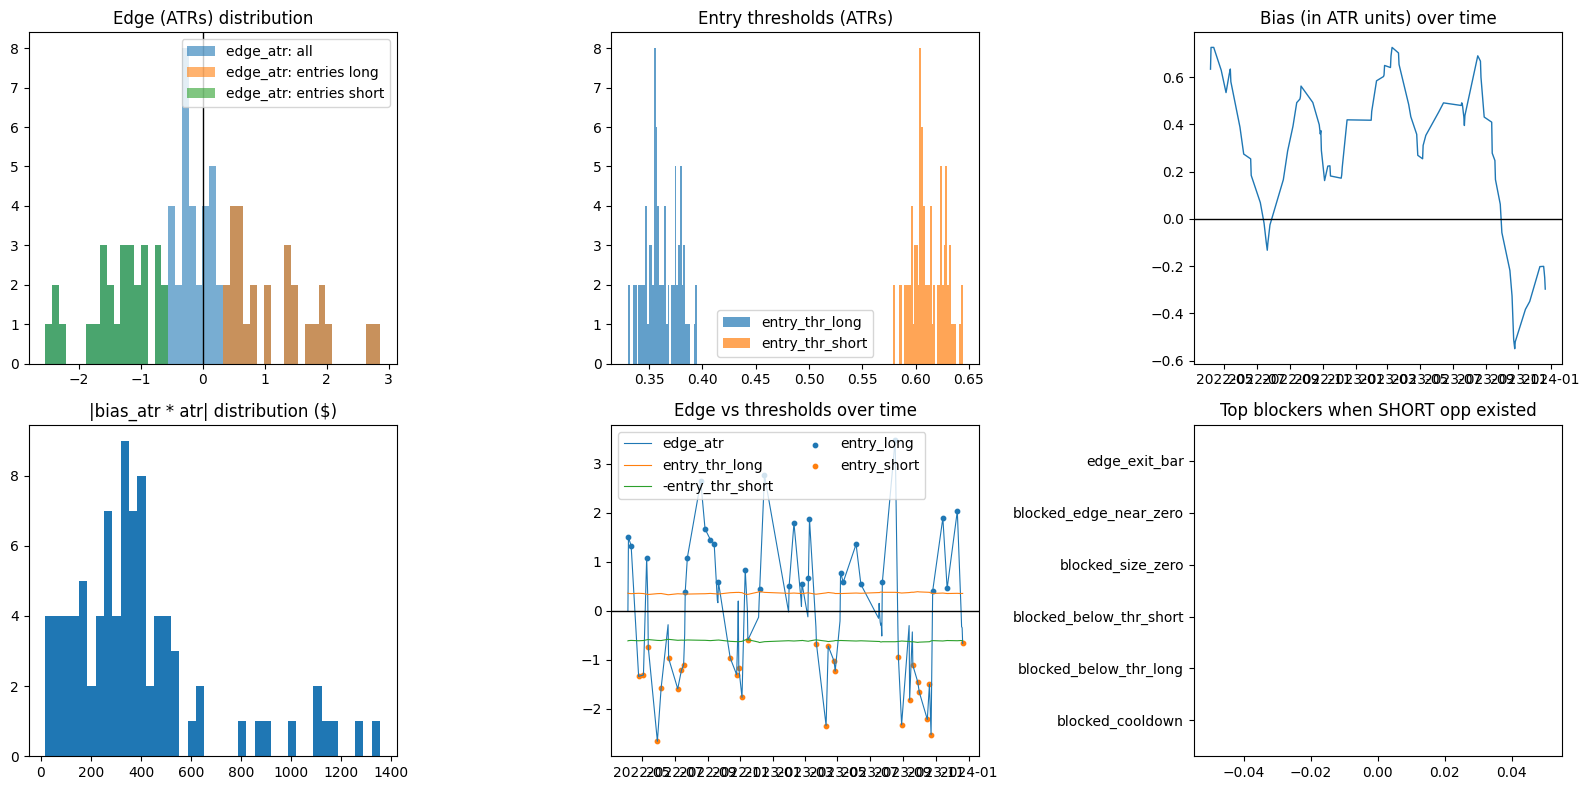

,side,opp_bars,entries,hit_rate,blocker1,blocker2,blocker3,blocker4,blocker5
0,LONG,28,28,1.0,blocked_cooldown:0.00,blocked_below_thr_long:0.00,blocked_below_thr_short:0.00,blocked_size_zero:0.00,blocked_edge_near_zero:0.00
1,SHORT,29,29,1.0,blocked_cooldown:0.00,blocked_below_thr_long:0.00,blocked_below_thr_short:0.00,blocked_size_zero:0.00,blocked_edge_near_zero:0.00


Saved -> decision_opportunity_summary.csv


In [5]:
# === Decision-log diagnostics: long/short opportunity analysis ===

# 1) Load
path = "decision_log.csv"  # change if needed
df = pd.read_csv(path)

# basic hygiene
for c in ["dt"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

num_cols = [
    "price","raw_pred","adj_pred","atr","bias_atr","edge_atr","cost_atr",
    "entry_thr_long","entry_thr_short","exit_thr_long","exit_thr_short",
    "trail_percent","stop_k","edge_strength_signed","pos_size",
    "cooldown","holding_bars","equity"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 2) Define opportunity/decision flags
df["opp_long"]  = df["edge_atr"] >  df["entry_thr_long"]
df["opp_short"] = df["edge_atr"] < -df["entry_thr_short"]

df["take_long"]  = df["decision"].eq("entry_long")
df["take_short"] = df["decision"].eq("entry_short")

# blockers we logged
blocked_cols = {
    "skip_cooldown":            "blocked_cooldown",
    "below_entry_thr_long":     "blocked_below_thr_long",
    "below_entry_thr_short":    "blocked_below_thr_short",
    "skip_size_zero":           "blocked_size_zero",
    "edge_near_zero":           "blocked_edge_near_zero",
    "edge_exit_triggered":      "edge_exit_bar",
    "max_hold_triggered":       "max_hold_bar",
    "in_position":              "already_in_pos",
}
for k, col in blocked_cols.items():
    df[col] = df["decision"].eq(k)

# 3) How many opportunities vs actions?
def _ratio(n, d): 
    return (n / d) if d else np.nan

summary = {
    "rows": len(df),
    "opp_long_bars": int(df["opp_long"].sum()),
    "opp_short_bars": int(df["opp_short"].sum()),
    "entries_long": int(df["take_long"].sum()),
    "entries_short": int(df["take_short"].sum()),
}
summary["hit_rate_long"]  = _ratio(summary["entries_long"],  summary["opp_long_bars"])
summary["hit_rate_short"] = _ratio(summary["entries_short"], summary["opp_short_bars"])

# blockers conditional on opportunities
block_cols = [v for v in blocked_cols.values()]
block_long = df.loc[df["opp_long"], block_cols].mean(numeric_only=True).sort_values(ascending=False)
block_short = df.loc[df["opp_short"], block_cols].mean(numeric_only=True).sort_values(ascending=False)

print("=== High-level ===")
for k, v in summary.items():
    print(f"{k:>18}: {v}")

print("\n=== When LONG opportunity existed, fraction of bars blocked by reason ===")
print((block_long.round(3)).to_string())

print("\n=== When SHORT opportunity existed, fraction of bars blocked by reason ===")
print((block_short.round(3)).to_string())

# 4) Edge & threshold distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

# edge histogram overall + split by action
bins = np.linspace(df["edge_atr"].quantile(0.01), df["edge_atr"].quantile(0.99), 50)
axes[0].hist(df["edge_atr"].dropna(), bins=bins, alpha=0.6, label="edge_atr: all")
axes[0].hist(df.loc[df["take_long"], "edge_atr"],  bins=bins, alpha=0.6, label="edge_atr: entries long")
axes[0].hist(df.loc[df["take_short"],"edge_atr"],  bins=bins, alpha=0.6, label="edge_atr: entries short")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_title("Edge (ATRs) distribution"); axes[0].legend()

# thresholds (entry)
axes[1].hist(df["entry_thr_long"].dropna(),  bins=40, alpha=0.7, label="entry_thr_long")
axes[1].hist(df["entry_thr_short"].dropna(), bins=40, alpha=0.7, label="entry_thr_short")
axes[1].set_title("Entry thresholds (ATRs)"); axes[1].legend()

# bias effect (how much raw_pred was shifted)
if {"raw_pred","adj_pred","atr","bias_atr"}.issubset(df.columns):
    df["bias_shift_$"] = (df["bias_atr"] * df["atr"]).abs()
    axes[2].plot(df["dt"], df["bias_atr"], lw=1)
    axes[2].axhline(0, color="k", lw=1)
    axes[2].set_title("Bias (in ATR units) over time")

    axes[3].hist(df["bias_shift_$"].dropna(), bins=40)
    axes[3].set_title("|bias_atr * atr| distribution ($)")

# opportunity heat vs decisions through time
axes[4].plot(df["dt"], df["edge_atr"], lw=0.8, label="edge_atr")
axes[4].plot(df["dt"], df["entry_thr_long"], lw=0.8, label="entry_thr_long")
axes[4].plot(df["dt"], -df["entry_thr_short"], lw=0.8, label="-entry_thr_short")
# mark entries
axes[4].scatter(df.loc[df["take_long"], "dt"],  df.loc[df["take_long"], "edge_atr"],  s=10, label="entry_long")
axes[4].scatter(df.loc[df["take_short"],"dt"],  df.loc[df["take_short"],"edge_atr"], s=10, label="entry_short")
axes[4].axhline(0, color="k", lw=1)
axes[4].set_title("Edge vs thresholds over time"); axes[4].legend(loc="upper left", ncol=2)

# blocker mix for SHORT opportunities
if df["opp_short"].any():
    blocker_mix_short = (df.loc[df["opp_short"], block_cols]
                         .mean(numeric_only=True)
                         .sort_values(ascending=False)[:6])
    axes[5].barh(blocker_mix_short.index, blocker_mix_short.values)
    axes[5].set_title("Top blockers when SHORT opp existed")
else:
    axes[5].axis("off")

plt.tight_layout()
plt.show()

# 5) Save a compact table you can scan quickly
out = []
for side, mask_opp, mask_take in [
    ("LONG",  df["opp_long"],  df["take_long"]),
    ("SHORT", df["opp_short"], df["take_short"]),
]:
    n_opp = int(mask_opp.sum())
    n_take = int(mask_take.sum())
    hit = _ratio(n_take, n_opp)
    row = dict(side=side, opp_bars=n_opp, entries=n_take, hit_rate=hit)
    # attach top blockers
    top = (df.loc[mask_opp, block_cols]
           .mean(numeric_only=True).sort_values(ascending=False).head(5))
    for i, (reason, frac) in enumerate(top.items(), 1):
        row[f"blocker{i}"] = f"{reason}:{frac:.2f}"
    out.append(row)

tbl = pd.DataFrame(out)
display(tbl)
tbl.to_csv("decision_opportunity_summary.csv", index=False)
print("Saved -> decision_opportunity_summary.csv")


In [6]:
# Ensure expected columns exist
dec = pd.read_csv("decision_log.csv")
required = {"dt","price","raw_pred","adj_pred","atr"}
missing = required - set(dec.columns)
assert not missing, f"decision_log is missing columns: {missing}"

# Parse date & sort
dec["dt"] = pd.to_datetime(dec["dt"])
dec = dec.sort_values("dt").reset_index(drop=True)

# Compute raw/adjusted edges in ATRs (raw is independent of bias correction)
eps = 1e-8
dec["raw_edge_atr"] = (dec["raw_pred"] - dec["price"]) / (dec["atr"] + eps)
# If your decision_log already has 'edge_atr' from the strategy, keep it;
# otherwise compute from adj_pred:
if "edge_atr" not in dec.columns:
    dec["edge_atr"] = (dec["adj_pred"] - dec["price"]) / (dec["atr"] + eps)

# Simple sign flags
dec["raw_sign"] = np.sign(dec["raw_edge_atr"])
dec["adj_sign"] = np.sign(dec["edge_atr"])

print("Rows:", len(dec))
print("Pct(raw_edge_atr > 0):", (dec["raw_edge_atr"] > 0).mean().round(4))
print("Pct(adj_edge_atr > 0):", (dec["edge_atr"] > 0).mean().round(4))

Rows: 88
Pct(raw_edge_atr > 0): 0.5568
Pct(adj_edge_atr > 0): 0.4432


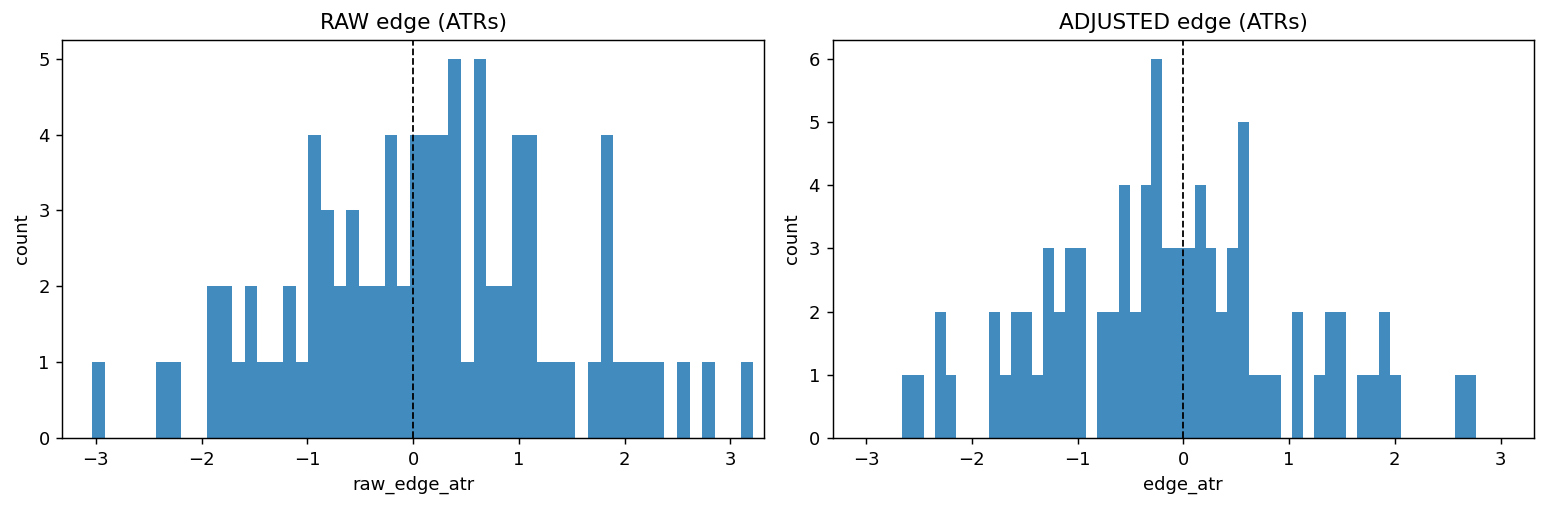

In [7]:
# Choose a symmetric x-range using robust percentiles of RAW edge
p1, p99 = np.percentile(dec["raw_edge_atr"].dropna(), [1, 99])
xlim = max(abs(p1), abs(p99))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=130)

axes[0].hist(dec["raw_edge_atr"].dropna(), bins=60, alpha=0.85)
axes[0].axvline(0, ls="--", lw=1, color="k")
axes[0].set_title("RAW edge (ATRs)")
axes[0].set_xlim(-xlim, xlim)
axes[0].set_xlabel("raw_edge_atr"); axes[0].set_ylabel("count")

axes[1].hist(dec["edge_atr"].dropna(), bins=60, alpha=0.85)
axes[1].axvline(0, ls="--", lw=1, color="k")
axes[1].set_title("ADJUSTED edge (ATRs)")
axes[1].set_xlim(-xlim, xlim)
axes[1].set_xlabel("edge_atr"); axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

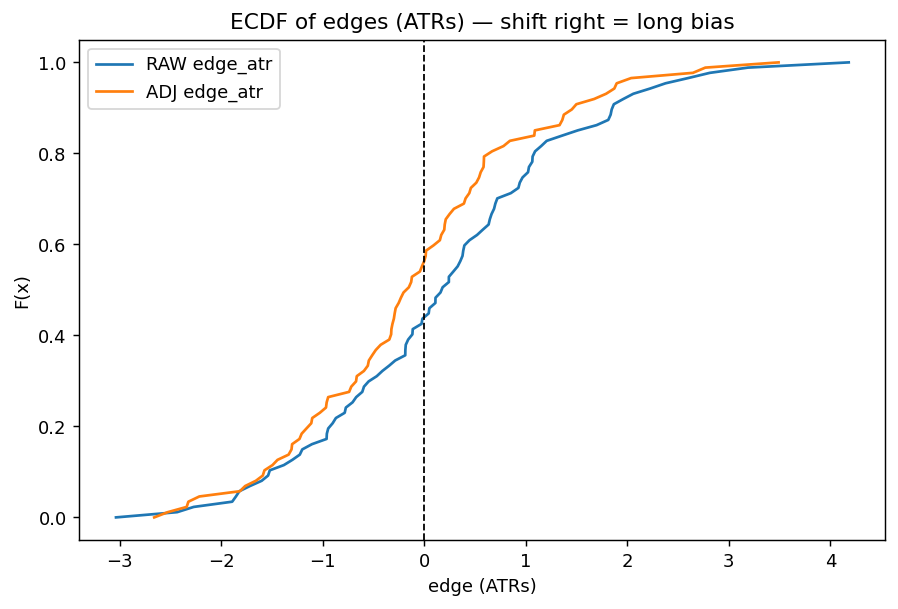

In [8]:
def ecdf(x):
    x = np.sort(x[~np.isnan(x)])
    y = np.linspace(0, 1, len(x), endpoint=True)
    return x, y

fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=130)
xr, yr = ecdf(dec["raw_edge_atr"].values)
xa, ya = ecdf(dec["edge_atr"].values)
ax.plot(xr, yr, label="RAW edge_atr")
ax.plot(xa, ya, label="ADJ edge_atr")
ax.axvline(0, ls="--", lw=1, color="k")
ax.set_title("ECDF of edges (ATRs) — shift right = long bias")
ax.set_xlabel("edge (ATRs)"); ax.set_ylabel("F(x)")
ax.legend()
plt.show()

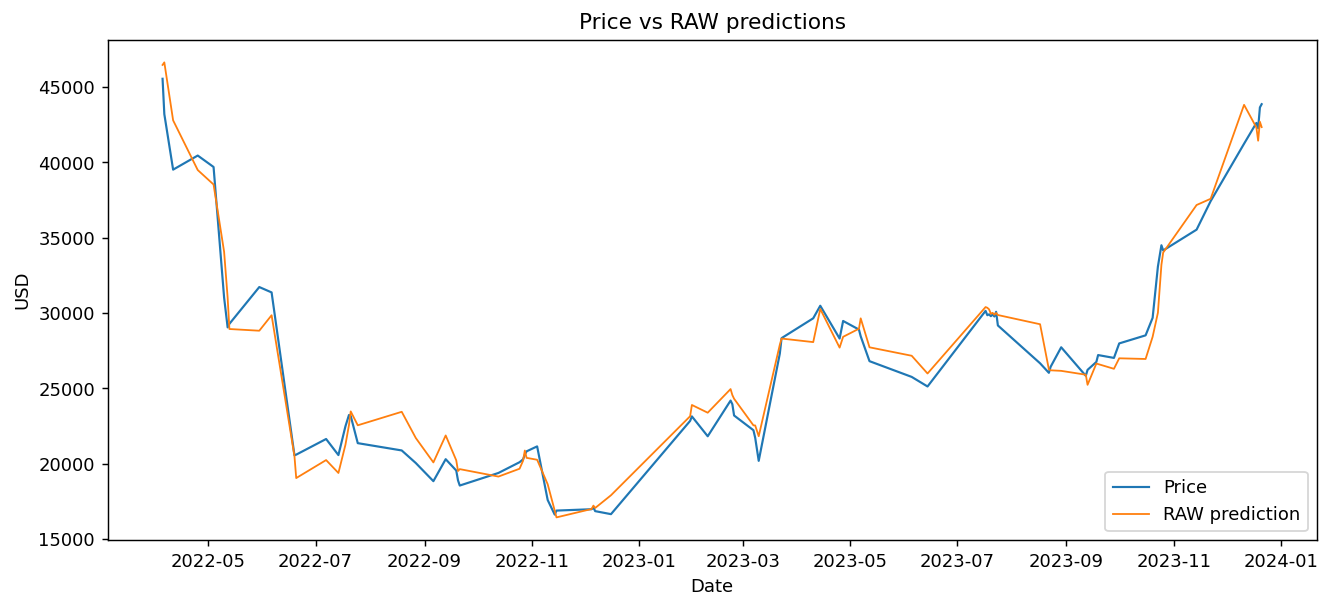

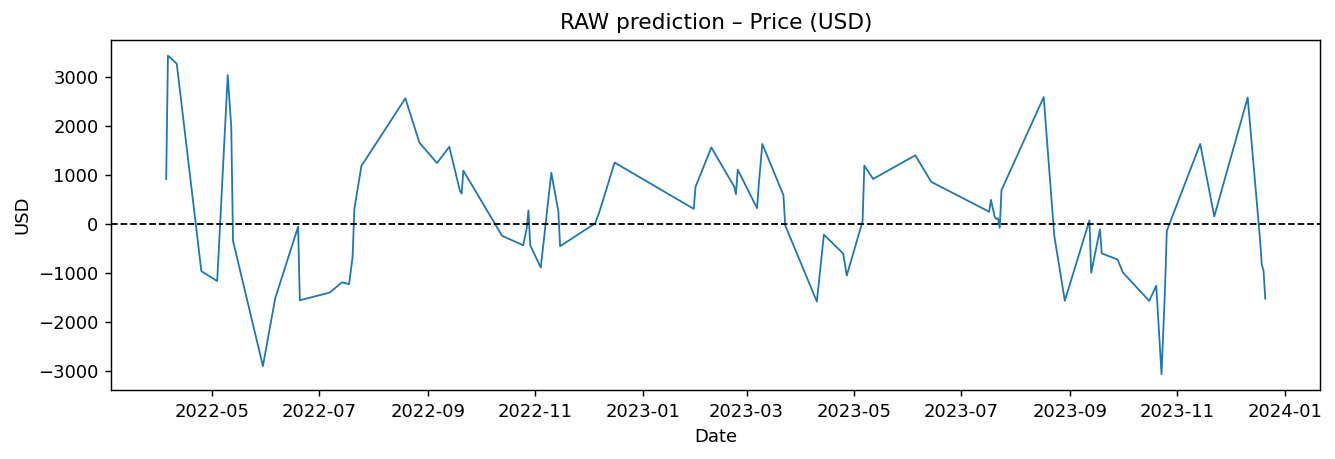

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5), dpi=130)
ax.plot(dec["dt"], dec["price"], lw=1.2, label="Price")
ax.plot(dec["dt"], dec["raw_pred"], lw=1.0, label="RAW prediction")
ax.set_title("Price vs RAW predictions")
ax.set_xlabel("Date"); ax.set_ylabel("USD")
ax.legend()
plt.show()

# Also the delta in $ (useful to see sign directly)
dec["raw_delta_$"] = dec["raw_pred"] - dec["price"]
fig, ax = plt.subplots(1, 1, figsize=(12, 3.5), dpi=130)
ax.plot(dec["dt"], dec["raw_delta_$"], lw=1.0)
ax.axhline(0, ls="--", lw=1, color="k")
ax.set_title("RAW prediction – Price (USD)")
ax.set_ylabel("USD"); ax.set_xlabel("Date")
plt.show()


In [10]:
summary = {
    "pct_positive_raw_edge": (dec["raw_edge_atr"] > 0).mean(),
    "pct_positive_adj_edge": (dec["edge_atr"] > 0).mean(),
    "median_raw_edge": np.median(dec["raw_edge_atr"]),
    "median_adj_edge": np.median(dec["edge_atr"]),
    "mean_raw_edge": dec["raw_edge_atr"].mean(),
    "mean_adj_edge": dec["edge_atr"].mean(),
}
pd.Series(summary).round(4)

pct_positive_raw_edge    0.5568
pct_positive_adj_edge    0.4432
median_raw_edge          0.1709
median_adj_edge         -0.1773
mean_raw_edge            0.1799
mean_adj_edge           -0.1129
dtype: float64